In [10]:
# Importamos Pandas y NumPy para el manejo de la base de datos.
import pandas as pd
import numpy as np

# Importamos Matplotlib para crear gráficas comparativas.
import matplotlib.pyplot as plt

# Importamos utilidades para dividir, escalar y muestrear.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Importamos el clasificador SVM (que internamente soporta distintos kernels).
from sklearn.svm import SVC

# Importamos métricas para evaluar y comparar los modelos.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
ruta = "us_congestion_2016_2022_sample_2m.csv"
df_completo = pd.read_csv(ruta)

columnas_X = ['Start_Lng', 'Start_Lat', 'DelayFromTypicalTraffic(mins)', 'Temperature(F)']
columna_y = 'Severity'

# Limpiamos nulos
df_svm = df_completo[columnas_X + [columna_y]].dropna()

# Filtro salvavidas: descartamos clases con menos de 5 registros
conteo_clases = df_svm[columna_y].value_counts()
clases_validas = conteo_clases[conteo_clases >= 5].index
df_svm = df_svm[df_svm[columna_y].isin(clases_validas)]

# Extraemos 20,000 registros estandarizados para que los kernels puedan compilar
df_muestra = resample(df_svm, n_samples=100000, random_state=42, stratify=df_svm[columna_y])

X_raw = df_muestra[columnas_X]
y = df_muestra[columna_y].values

# ESCALAMOS LOS DATOS (Obligatorio para comparar distancias geométricas)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Shape de X (Datos escalados):", X.shape)
print("Shape de y:", y.shape)
print("Distribución de Severidad en la muestra:\n", df_muestra[columna_y].value_counts())

Shape de X (Datos escalados): (100000, 4)
Shape de y: (100000,)
Distribución de Severidad en la muestra:
 Severity
1    46699
2    26181
0    24311
3     2809
Name: count, dtype: int64


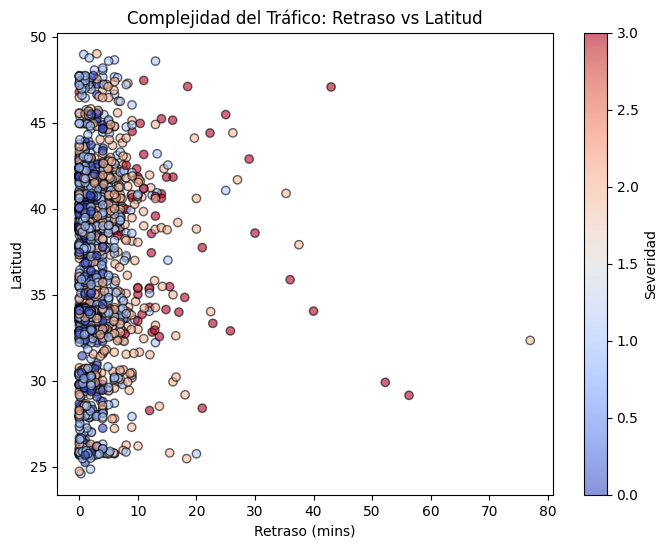

In [12]:
_, ax = plt.subplots(figsize=(8, 6))

# Usamos una sub-muestra para que la gráfica no sea una mancha ilegible
scatter = ax.scatter(
    X_raw.iloc[:2000, 2],       # Retraso Típico
    X_raw.iloc[:2000, 1],       # Latitud
    c=y[:2000],                 # Color según Severidad
    cmap="coolwarm",            # Paleta de colores
    edgecolors="k",
    alpha=0.6
)

ax.set_title("Complejidad del Tráfico: Retraso vs Latitud")
ax.set_xlabel("Retraso (mins)")
ax.set_ylabel("Latitud")
plt.colorbar(scatter, label="Severidad")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                  
    y,                  
    test_size=0.2,      # 20% para prueba (4,000 registros)
    random_state=42,    
    stratify=y          
)

print("Shape de X_train (Entrenamiento):", X_train.shape)
print("Shape de X_test (Prueba):", X_test.shape)

Shape de X_train (Entrenamiento): (80000, 4)
Shape de X_test (Prueba): (20000, 4)


In [14]:
print("Iniciando entrenamiento de modelos... Esto tomará un momento.")

# 1. Creamos y entrenamos el modelo lineal (Base de comparación)
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
print("✓ Modelo Lineal entrenado.")

# 2. Creamos y entrenamos el modelo Polinómico
svm_poly = SVC(kernel="poly", degree=3, C=1.0, gamma="scale", random_state=42)
svm_poly.fit(X_train, y_train)
print("✓ Modelo Polinómico entrenado.")

# 3. Creamos y entrenamos el modelo RBF (Radial Basis Function)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_train, y_train)
print("✓ Modelo RBF entrenado.")

print("¡Los tres modelos están listos!")

Iniciando entrenamiento de modelos... Esto tomará un momento.
✓ Modelo Lineal entrenado.
✓ Modelo Polinómico entrenado.
✓ Modelo RBF entrenado.
¡Los tres modelos están listos!


In [15]:
# Generamos predicciones
pred_linear = svm_linear.predict(X_test)
pred_poly = svm_poly.predict(X_test)
pred_rbf = svm_rbf.predict(X_test)

# Calculamos Exactitud (Accuracy)
acc_linear = accuracy_score(y_test, pred_linear)
acc_poly = accuracy_score(y_test, pred_poly)
acc_rbf = accuracy_score(y_test, pred_rbf)

print(f"Accuracy Kernel Lineal:     {acc_linear * 100:.2f}%")
print(f"Accuracy Kernel Polinómico: {acc_poly * 100:.2f}%")
print(f"Accuracy Kernel RBF:        {acc_rbf * 100:.2f}%")

Accuracy Kernel Lineal:     49.57%
Accuracy Kernel Polinómico: 49.77%
Accuracy Kernel RBF:        51.95%


In [16]:
# Seleccionamos el mejor modelo basado en Accuracy
resultados = [("Lineal", acc_linear), ("Polinómico", acc_poly), ("RBF", acc_rbf)]
best_name = max(resultados, key=lambda x: x[1])[0]

best_model = svm_linear if best_name == "Lineal" else svm_poly if best_name == "Polinómico" else svm_rbf
best_pred = pred_linear if best_name == "Lineal" else pred_poly if best_name == "Polinómico" else pred_rbf

print(f"🥇 El mejor kernel fue: {best_name}")

print("\nMatriz de confusión del ganador:")
print(confusion_matrix(y_test, best_pred))

print("\nReporte de clasificación detallado:")
print(classification_report(y_test, best_pred, zero_division=0))

🥇 El mejor kernel fue: RBF

Matriz de confusión del ganador:
[[ 687 4091   84    0]
 [ 458 7552 1325    5]
 [ 102 3008 2094   32]
 [   3  125  376   58]]

Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.55      0.14      0.22      4862
           1       0.51      0.81      0.63      9340
           2       0.54      0.40      0.46      5236
           3       0.61      0.10      0.18       562

    accuracy                           0.52     20000
   macro avg       0.55      0.36      0.37     20000
weighted avg       0.53      0.52      0.47     20000



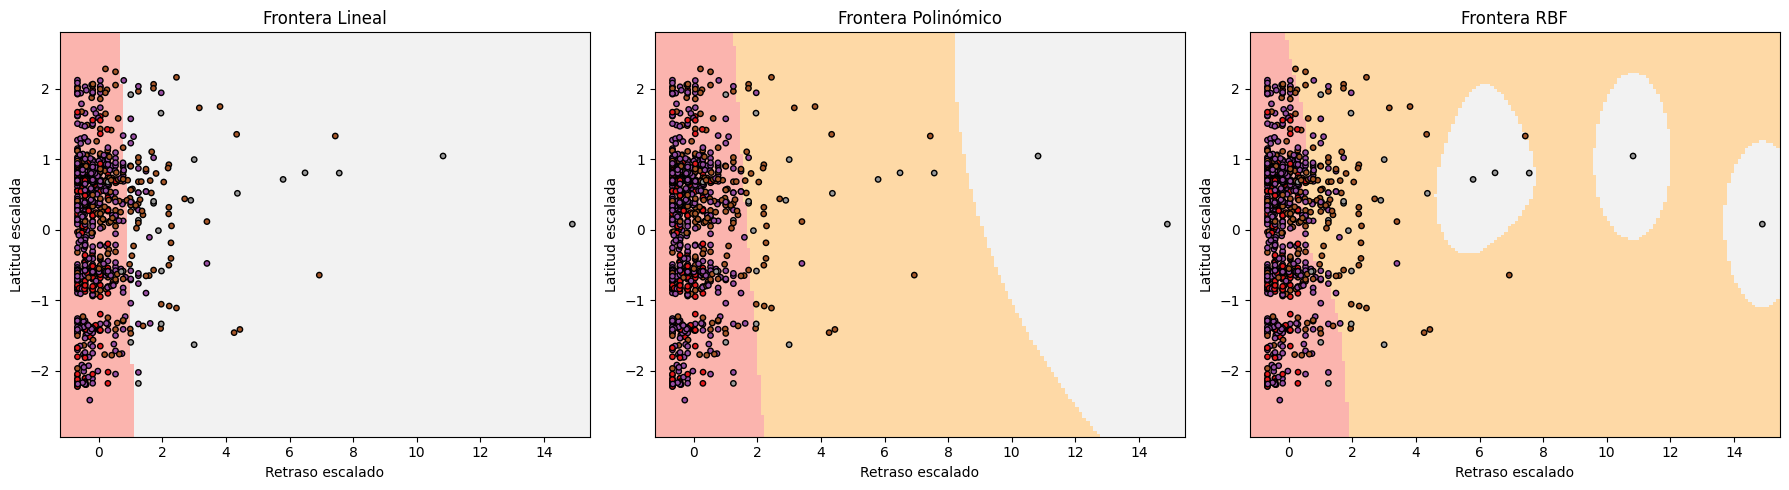

In [17]:
# Tomamos solo 2 variables (Retraso y Latitud) y 1000 datos para graficar
X_vis = X_train[:1000, [2, 1]] 
y_vis = y_train[:1000]

# Entrenamos versiones ligeras 2D
svm_lin_vis = SVC(kernel="linear").fit(X_vis, y_vis)
svm_poly_vis = SVC(kernel="poly", degree=3).fit(X_vis, y_vis)
svm_rbf_vis = SVC(kernel="rbf").fit(X_vis, y_vis)

# Malla
offset = 0.5
x_min, x_max = X_vis[:, 0].min() - offset, X_vis[:, 0].max() + offset
y_min, y_max = X_vis[:, 1].min() - offset, X_vis[:, 1].max() + offset
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid_points = np.c_[x_grid.ravel(), y_grid.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
modelos = [(svm_lin_vis, "Lineal"), (svm_poly_vis, "Polinómico"), (svm_rbf_vis, "RBF")]

for ax, (modelo, titulo) in zip(axes, modelos):
    pred_grid = modelo.predict(grid_points).reshape(x_grid.shape)
    ax.pcolormesh(x_grid, y_grid, pred_grid, cmap="Pastel1", shading="auto")
    ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap="Set1", edgecolors="k", s=15)
    ax.set_title(f"Frontera {titulo}")
    ax.set_xlabel("Retraso escalado")
    ax.set_ylabel("Latitud escalada")

plt.tight_layout()
plt.show()

In [18]:
# Simulamos un nuevo evento: [Longitud, Latitud, Retraso, Temperatura]
nuevo_evento = np.array([[-74.00, 40.71, 120.0, 30.0]]) # NYC en invierno con 2 horas de retraso

# Escalamos
nuevo_evento_escalado = scaler.transform(nuevo_evento)

# Predecimos con el campeón
pred_nuevo = best_model.predict(nuevo_evento_escalado)[0]

print("Nuevo evento de tráfico (Lng, Lat, Retraso, Temp):", nuevo_evento[0])
print(f"Severidad predicha por el Kernel {best_name}: Clase {pred_nuevo}")

Nuevo evento de tráfico (Lng, Lat, Retraso, Temp): [-74.    40.71 120.    30.  ]
Severidad predicha por el Kernel RBF: Clase 3


c:\Users\USUARIO\Documents\Semestre9\ML\MachineLearning\Week_4_5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
